In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
covid = pd.read_excel(r'C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset\COVID.metadata.xlsx')
normal = pd.read_excel(r'C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset\Normal.metadata.xlsx')
lung = pd.read_excel(r'C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset\Lung_Opacity.metadata.xlsx')
pneumonia = pd.read_excel(r'C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset\Viral Pneumonia.metadata.xlsx')

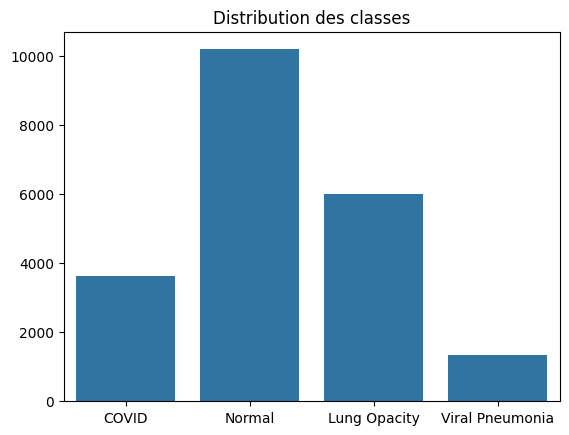

In [4]:
classes = {'COVID': len(covid), 'Normal': len(normal), 
           'Lung Opacity': len(lung), 'Viral Pneumonia': len(pneumonia)}
sns.barplot(x=list(classes.keys()), y=list(classes.values()))
plt.title("Distribution des classes")
plt.show()

## Distribution des classes

Le dataset présente un déséquilibre important entre les classes :
- Normal est très majoritaire (10 192 images)
- Viral Pneumonia est très minoritaire (1 345 images)

Ce déséquilibre devra être pris en compte lors de la modélisation 
(data augmentation, class weights).

## Source des images

Les images COVID proviennent de 4 sources différentes :
- 2473 images de PadChest
- 183 images d'une école médicale allemande
- 559 images de SIRM, Github, Kaggle
- 400 images d'une autre source Github

Le modèle pourrait apprendre des artefacts techniques 
propres à chaque source plutôt que les caractéristiques médicales du Covid.

Normalisation des images en pre-processing ?

In [5]:
def get_source(url):
    if 'sirm' in str(url): return 'SIRM'
    elif 'github' in str(url): return 'Github'
    elif 'kaggle' in str(url): return 'Kaggle'
    elif 'padchest' in str(url) or 'bimcv' in str(url): return 'PadChest'
    elif 'figshare' in str(url): return 'Figshare'
    else: return 'Autre'

covid['source'] = covid['URL'].apply(get_source)
covid['source'].value_counts()

source
PadChest    2474
Github       765
Autre        258
SIRM         119
Name: count, dtype: int64

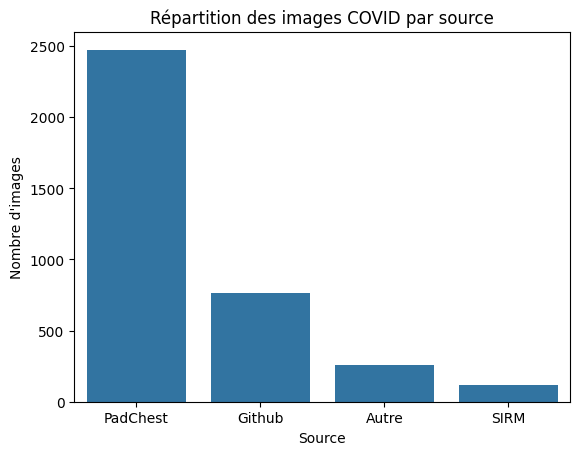

In [6]:
sns.barplot(x=covid['source'].value_counts().index, 
            y=covid['source'].value_counts().values)
plt.title("Répartition des images COVID par source")
plt.xlabel("Source")
plt.ylabel("Nombre d'images")
plt.show()

In [7]:
import cv2

base = r"C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset"

img = cv2.imread(base + r"\COVID\images\COVID-1.png")
mask = cv2.imread(base + r"\COVID\masks\COVID-1.png")

print("Image :", img.shape)
print("Masque :", mask.shape)

Image : (299, 299, 3)
Masque : (256, 256, 3)


In [8]:
def get_source(url):
    if 'sirm' in str(url): return 'SIRM'
    elif 'github' in str(url): return 'Github'
    elif 'kaggle' in str(url): return 'Kaggle'
    elif 'padchest' in str(url) or 'bimcv' in str(url): return 'PadChest'
    elif 'figshare' in str(url): return 'Figshare'
    else: return 'Autre'

covid['source'] = covid['URL'].apply(get_source)

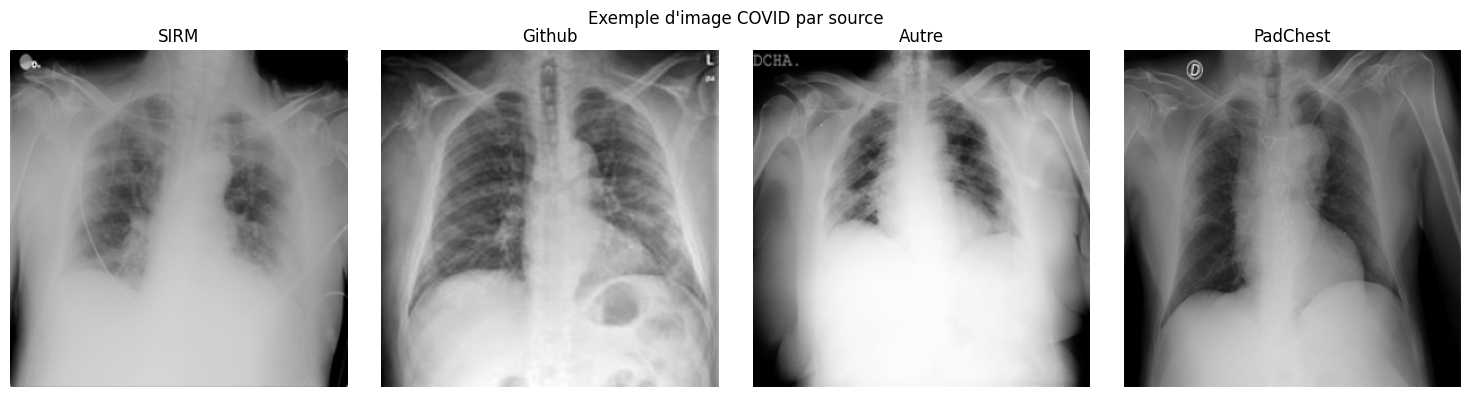

In [9]:
import cv2

base_path = r"C:\Users\Maxime\Desktop\Projet COVID19\COVID-19_Radiography_Dataset"
sources = covid['source'].unique()

fig, axes = plt.subplots(1, len(sources), figsize=(15, 4))

for i, source in enumerate(sources):
    fichier = covid[covid['source'] == source]['FILE NAME'].iloc[0]
    img_path = base_path + r"\COVID\images\\" + fichier + ".png"
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(source)
    axes[i].axis('off')

plt.suptitle("Exemple d'image COVID par source")
plt.tight_layout()
plt.show()

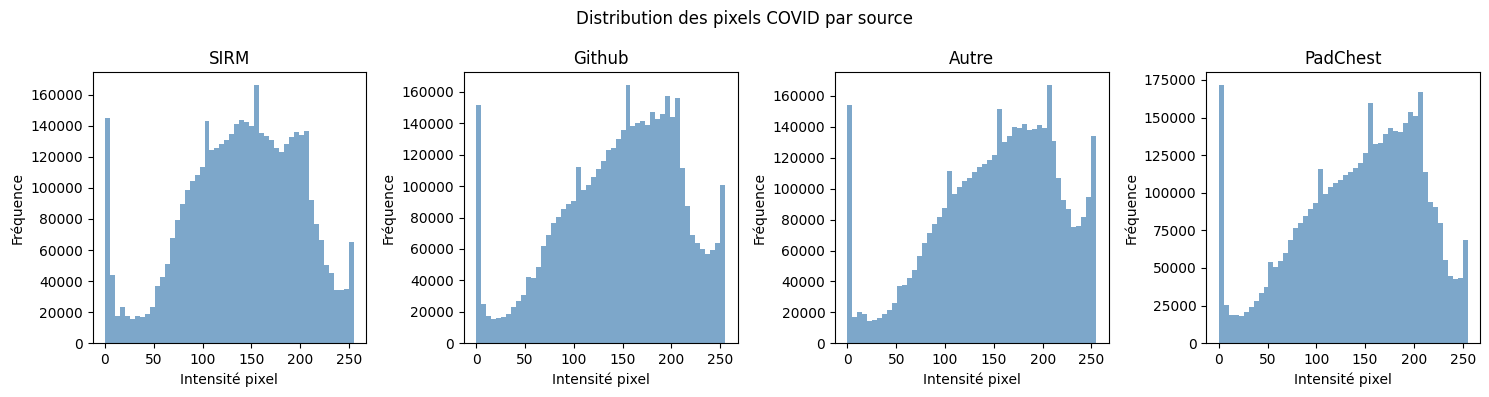

In [10]:
fig, axes = plt.subplots(1, len(sources), figsize=(15, 4))

for i, source in enumerate(sources):
    # Récupère toutes les images de cette source
    fichiers = covid[covid['source'] == source]['FILE NAME'].tolist()
    
    # Calcule la moyenne des pixels de quelques images
    pixels = []
    for fichier in fichiers[:50]:  # on prend les 50 premières pour aller vite
        img_path = base_path + r"\COVID\images\\" + fichier + ".png"
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            pixels.extend(img.flatten().tolist())
    
    axes[i].hist(pixels, bins=50, color='steelblue', alpha=0.7)
    axes[i].set_title(source)
    axes[i].set_xlabel('Intensité pixel')
    axes[i].set_ylabel('Fréquence')

plt.suptitle("Distribution des pixels COVID par source")
plt.tight_layout()
plt.show()

## Analyse de la distribution des pixels COVID par source

### Méthodologie
Pour chaque source (SIRM, Github, Autre, PadChest), nous avons :
1. Sélectionné les 50 premières images COVID de cette source
2. Chargé chaque image en niveaux de gris (valeurs de 0 à 255)
3. **Sans application des masques** — les images brutes sont analysées ici
4. Aplati les pixels en listes et tracé leur distribution

### Interprétation des valeurs
- **0 (noir)** → fond de l'image, zones hors poumons, ou zones masquées
- **1-100 (gris sombre)** → tissus pulmonaires sains, zones peu denses
- **100-200 (gris moyen)** → structures pulmonaires, vaisseaux
- **200-255 (blanc)** → zones très denses : os (côtes, colonne), opacités pathologiques, 
  potentiellement des annotations ou artefacts médicaux

### Observations
- Les 4 sources ont des profils globalement similaires — rassurant pour l'homogénéité du dataset
- **PadChest** se distingue avec un pic à 0 plus élevé — proportion plus importante 
  de pixels noirs, suggérant des images avec plus de fond ou un cadrage différent
- Les pics à 255 présents dans toutes les sources indiquent des zones très blanches 
  potentiellement liées à des artefacts ou annotations radiologiques
- L'hétérogénéité reste limitée — une normalisation en pre-processing devrait suffire 
  à harmoniser les sources

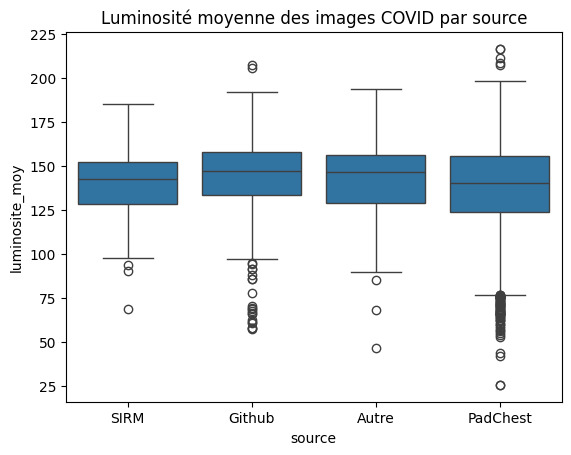

In [11]:
covid['luminosite_moy'] = covid['FILE NAME'].apply(
    lambda f: cv2.imread(base_path + r"\COVID\images\\" + f + ".png", 
                         cv2.IMREAD_GRAYSCALE).mean()
)

sns.boxplot(x='source', y='luminosite_moy', data=covid)
plt.title("Luminosité moyenne des images COVID par source")
plt.show()

## Luminosité moyenne des images COVID par source

### Méthodologie
Pour chaque image COVID, nous avons calculé la luminosité moyenne, 
c'est-à-dire la moyenne de toutes les valeurs de pixels (0-255) de l'image 
en niveaux de gris, **sans application des masques**.
Cette valeur résume en un seul chiffre la clarté globale de l'image.

### Observations
- **SIRM, Github et Autre** ont des distributions très similaires, 
  centrées autour de 140-150 avec une dispersion comparable
- **PadChest** a une médiane légèrement plus basse (~135) et surtout 
  une dispersion bien plus grande, de nombreuses valeurs aberrantes 
  vers le bas (images très sombres, jusqu'à 25-30)
- Ces images très sombres de PadChest correspondent probablement à des 
  radiographies sous-exposées ou avec un cadrage différent

### Conclusion
Les 3 premières sources sont relativement homogènes entre elles.
PadChest introduit plus de variabilité dans la luminosité, 
ce qui confirme l'observation faite sur les histogrammes de pixels.
Une normalisation de la luminosité en pre-processing sera particulièrement 
importante pour harmoniser les images PadChest avec le reste du dataset.

### Nuance importante
PadChest représente 2474 images sur 3616 au total (68% du dataset COVID) — 
sa plus grande variabilité peut donc s'expliquer en partie par le simple 
fait d'avoir beaucoup plus d'images, et donc plus de chances d'avoir 
des cas extrêmes. Il faudra garder cela en tête avant de conclure 
que PadChest est intrinsèquement plus hétérogène que les autres sources.